In [ ]:
# ==============================================================================
# SCRIPT: Sentiment Analysis Pipeline (FINAL VERSION)
# ==============================================================================

import re
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from transformers import pipeline

# --------------------------------
# 1. SETUP AND CONFIGURATION
# --------------------------------

# --- File Names ---
INPUT_FILE = 'Data1-clean.csv'
CLEANED_FILE = 'cleaning.csv'
OUTPUT_FILE = 'final_sentiment_categorized.csv'

# --- Normalization Dictionary ---
normalization_dict = {
    # (The dictionary is long, so it's omitted here for brevity, but it is included in the full code block below)
    'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk', 'kpd': 'kepada',
    'dr': 'dari', 'karna': 'karena', 'krn': 'karena', 'bkn': 'bukan',
    'jg': 'juga', 'sdh': 'sudah', 'udh': 'sudah', 'udah': 'sudah',
    'blm': 'belum', 'thn': 'tahun', 'tgl': 'tanggal', 'dll': 'dan lain lain',
    'dsb': 'dan sebagainya', 'sbg': 'sebagai', 'tdk': 'tidak',
    'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'jgn': 'jangan',
    'bnyk': 'banyak', 'dpt': 'dapat', 'aja': 'saja', 'sja': 'saja',
    'trus': 'terus', 'trs': 'terus', 'gw': 'saya', 'gue': 'saya', 'ane': 'saya', 
    'sy': 'saya', 'lu': 'kamu', 'loe': 'kamu', 'klen': 'kalian', 'bgt': 'banget', 
    'mantul': 'mantap', 'keren': 'bagus', 'oke': 'baik', 'bagus': 'baik', 
    'mantap': 'baik', 'top': 'baik', 'recommended': 'bagus', 'gokil': 'luar biasa', 
    'amazing': 'luar biasa', 'wow': 'luar biasa', 'perfect': 'sempurna', 
    'excellent': 'sangat baik', 'jelek': 'buruk', 'parah': 'buruk', 'gaje': 'buruk', 
    'zonk': 'buruk', 'disappointing': 'mengecewakan', 'terrible': 'buruk', 
    'awful': 'buruk', 'hate': 'benci', 'sucks': 'buruk', 'worst': 'terburuk',
    'rubbish': 'sampah', 'useless': 'tidak berguna', 'waste': 'buruk', 'mulyono': 'buruk',
    'cuman': 'cuma', 'emang': 'memang', 'kalo': 'kalau', 'klo': 'kalau', 'pake': 'pakai', 
    'jd': 'jadi', 'lg': 'lagi', 'emg': 'memang', 'kyk': 'seperti', 'kek': 'seperti', 
    'hny': 'hanya', 'knp': 'kenapa', 'gmn': 'bagaimana', 'kpn': 'kapan', 'brp': 'berapa',
    'sblm': 'sebelum', 'stlh': 'setelah',
}

# --------------------------------
# 2. HELPER FUNCTIONS
# --------------------------------

def clean_text_improved(text, stemmer, custom_stopwords):
    """Improved text cleaning function that preserves sentiment"""
    if pd.isna(text):
        return ''
    
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[!]{2,}', ' sangat ', text)
    text = re.sub(r'[?]{2,}', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = text.split()
    tokens = [normalization_dict.get(tok, tok) for tok in tokens]
    tokens = [tok for tok in tokens if len(tok) >= 2 or tok in ['ga', 'ng']]
    tokens = [tok for tok in tokens if tok not in custom_stopwords]
    
    sentiment_preserve = {'bagus', 'buruk', 'jelek', 'baik', 'suka', 'benci', 'senang', 'sedih'}
    tokens = [tok if tok in sentiment_preserve else stemmer.stem(tok) for tok in tokens]
    
    return ' '.join(tokens)

def analyze_sentiment_improved(texts, sentiment_analyzer, batch_size=16):
    """Improved sentiment analysis with confidence handling"""
    results = []
    total_texts = len(texts)
    for i in range(0, total_texts, batch_size):
        batch = texts[i:i+batch_size]
        
        try:
            # The pipeline is much faster when processing a batch of texts
            batch_results_raw = sentiment_analyzer(batch)
            
            for scores in batch_results_raw:
                best_pred = max(scores, key=lambda x: x['score'])
                results.append({
                    'label': best_pred['label'],
                    'score': best_pred['score'],
                    'all_scores': scores
                })
        except Exception as e:
            print(f"Error processing a batch: {e}. Processing one-by-one as fallback.")
            # Fallback to one-by-one processing for the failed batch
            for text in batch:
                try:
                    scores = sentiment_analyzer(text)[0] # sentiment_analyzer returns a list of lists for single string
                    best_pred = max(scores, key=lambda x: x['score'])
                    results.append({'label': best_pred['label'], 'score': best_pred['score'], 'all_scores': scores})
                except Exception as e_single:
                    print(f"Error processing single text: '{text[:50]}...'. Error: {e_single}")
                    results.append({'label': 'NEUTRAL', 'score': 0.5, 'all_scores': [{'label': 'NEUTRAL', 'score': 0.5}]})

        if (i // batch_size + 1) % 10 == 0:
            print(f"Processed {min(i + batch_size, total_texts)}/{total_texts} texts")
    return results

def map_to_final_sentiment(row, model_type, confidence_threshold=0.6):
    """Maps raw model output to a final positive/negative/neutral category."""
    label = row['raw_sentiment_label'].upper()
    score = row['raw_sentiment_score']
    
    if score < confidence_threshold:
        return 'neutral'
    
    mapping = {
        "ayameRushia": {'POSITIVE': 'positive', 'NEGATIVE': 'negative'},
        "xlm-roberta": {'POSITIVE': 'positive', 'NEGATIVE': 'negative', 'NEUTRAL': 'neutral'}
    }
    
    if model_type in mapping:
        return mapping[model_type].get(label, 'neutral')
    
    return 'neutral' # Default case

# --------------------------------
# 3. MAIN EXECUTION
# --------------------------------

if __name__ == "__main__":
    
    # --- PART 1: TEXT CLEANING ---
    print("--- Starting Part 1: Text Cleaning ---")
    try:
        df = pd.read_csv(INPUT_FILE)
        print(f"Successfully loaded {INPUT_FILE}. It has {len(df)} rows.")
    except FileNotFoundError:
        print(f"FATAL ERROR: The input file was not found at '{INPUT_FILE}'")
        exit()

    # Initialize Sastrawi tools
    stem_factory = StemmerFactory()
    stemmer = stem_factory.create_stemmer()
    
    stop_factory = StopWordRemoverFactory()
    default_stopwords = set(stop_factory.get_stop_words())
    sentiment_words = {
        'tidak', 'bukan', 'jangan', 'kurang', 'buruk', 'jelek', 'bagus', 'baik', 
        'suka', 'senang', 'sedih', 'marah', 'kecewa', 'puas', 'mantap', 'hebat',
        'luar', 'biasa', 'sempurna', 'terburuk', 'terbaik', 'recommended'
    }
    custom_stopwords = default_stopwords - sentiment_words

    # =========================================================================
    # <-- IMPORTANT: The column name has been updated to match your CSV file.
    SOURCE_COLUMN_NAME = 'cleaned_text' 
    # =========================================================================
    
    if SOURCE_COLUMN_NAME not in df.columns:
        print(f"FATAL ERROR: Source column '{SOURCE_COLUMN_NAME}' not found in the CSV.")
        print(f"Available columns are: {list(df.columns)}")
        exit()

    print(f"Applying text cleaning on column '{SOURCE_COLUMN_NAME}'...")
    df['text_cleaned'] = df[SOURCE_COLUMN_NAME].apply(lambda x: clean_text_improved(x, stemmer, custom_stopwords))
    
    # Filter and save intermediate file
    original_rows = len(df)
    df = df[df['text_cleaned'].str.len() > 10].reset_index(drop=True)
    print(f"Filtered out {original_rows - len(df)} short/empty texts. Remaining rows: {len(df)}")
    df.to_csv(CLEANED_FILE, index=False)
    print(f"Cleaned data saved to {CLEANED_FILE}\n")


    # --- PART 2: SENTIMENT ANALYSIS ---
    print("--- Starting Part 2: Sentiment Analysis ---")
    model_type = ""
    try:
        sentiment_analyzer = pipeline("sentiment-analysis", model="ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa", device=-1, return_all_scores=True)
        model_type = "ayameRushia"
        print("Using ayameRushia model.")
    except Exception as e:
        print(f"Could not load primary model: {e}. Trying fallback.")
        try:
            sentiment_analyzer = pipeline("sentiment-analysis", model="cardiffnlp/twitter-xlm-roberta-base-sentiment", device=-1, return_all_scores=True)
            model_type = "xlm-roberta"
            print("Using XLM-RoBERTa fallback model.")
        except Exception as e_fallback:
            print(f"FATAL ERROR: Could not load any sentiment analysis model: {e_fallback}")
            exit()
            
    print("Running sentiment analysis on cleaned text...")
    sentiment_results = analyze_sentiment_improved(df['text_cleaned'].tolist(), sentiment_analyzer)
    
    df['raw_sentiment_label'] = [r['label'] for r in sentiment_results]
    df['raw_sentiment_score'] = [r['score'] for r in sentiment_results]
    print("Sentiment analysis complete.\n")

    
    # --- PART 3: MAPPING AND POST-PROCESSING ---
    print("--- Starting Part 3: Final Mapping and Validation ---")
    df['sentiment_category'] = df.apply(lambda row: map_to_final_sentiment(row, model_type), axis=1)

    def categorize_confidence(score):
        if score >= 0.8: return 'high'
        if score >= 0.6: return 'medium'
        return 'low'
    
    df['confidence_level'] = df['raw_sentiment_score'].apply(categorize_confidence)

    print("\n=== SENTIMENT ANALYSIS RESULTS ===")
    print("Sentiment Distribution:")
    print(df['sentiment_category'].value_counts())
    print("\nConfidence Distribution:")
    print(df['confidence_level'].value_counts())
    print("\nCross-tabulation:")
    print(pd.crosstab(df['sentiment_category'], df['confidence_level']))

    # Save final results
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"\nPipeline completed. Final results saved to {OUTPUT_FILE}")

    # Show sample results
    print("\n=== SAMPLE RESULTS ===")
    sample_df = df[[SOURCE_COLUMN_NAME, 'text_cleaned', 'sentiment_category', 'raw_sentiment_score']].head(10)
    print(sample_df.to_string())

--- Starting Part 1: Text Cleaning ---
Successfully loaded Data1-clean.csv. It has 6532 rows.
Applying text cleaning on column 'cleaned_text'...



--- Memulai Part 5: Evaluasi Model Lengkap ---
Berhasil memuat data untuk pemodelan: 6260 baris.

--- A. Evaluasi dengan Single Split (80/20) ---

--- Melatih Model KNN (Single Split) ---
Akurasi KNN: 0.4297
Laporan Klasifikasi KNN (mencakup Presisi, Recall, F1-Score):
              precision    recall  f1-score   support

    negative       0.48      0.22      0.30       481
     neutral       0.49      0.62      0.55       544
    positive       0.27      0.41      0.33       227

    accuracy                           0.43      1252
   macro avg       0.42      0.42      0.39      1252
weighted avg       0.45      0.43      0.41      1252


--- Melatih Model SVM (Single Split) ---
Akurasi SVM: 0.7141
Laporan Klasifikasi SVM (mencakup Presisi, Recall, F1-Score):
              precision    recall  f1-score   support

    negative       0.74      0.79      0.77       481
     neutral       0.69      0.78      0.73       544
    positive       0.72      0.38      0.50       227

    ac

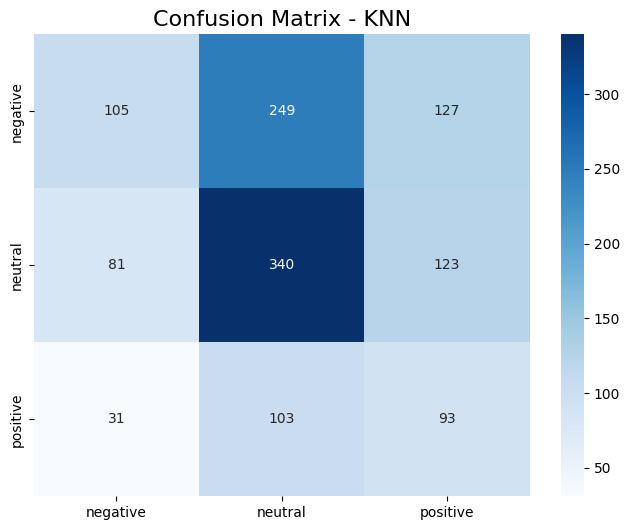

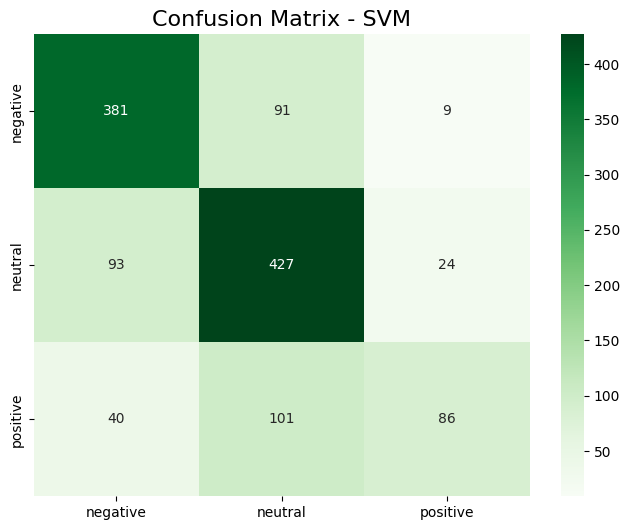

Mengurangi dimensi untuk visualisasi scatterplot...


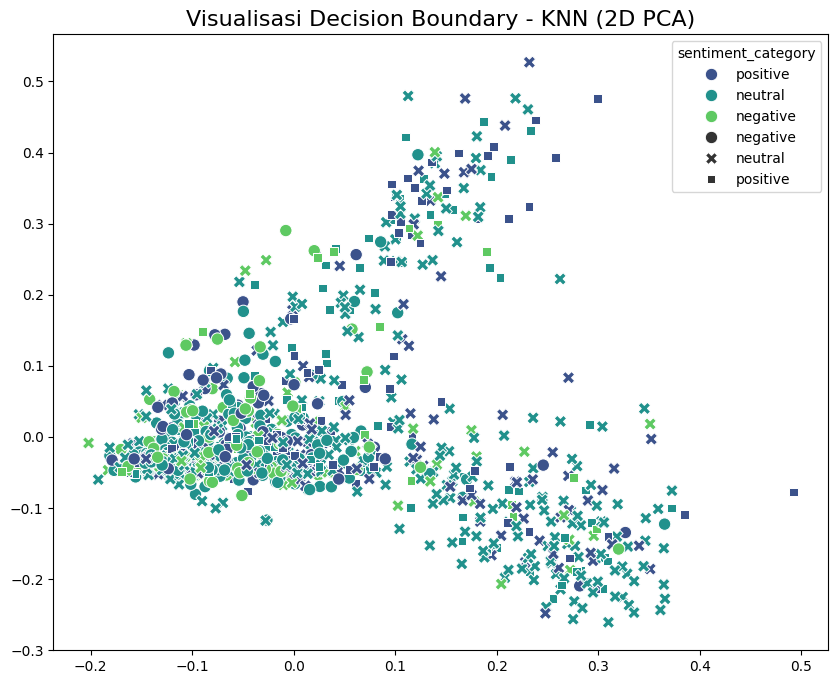

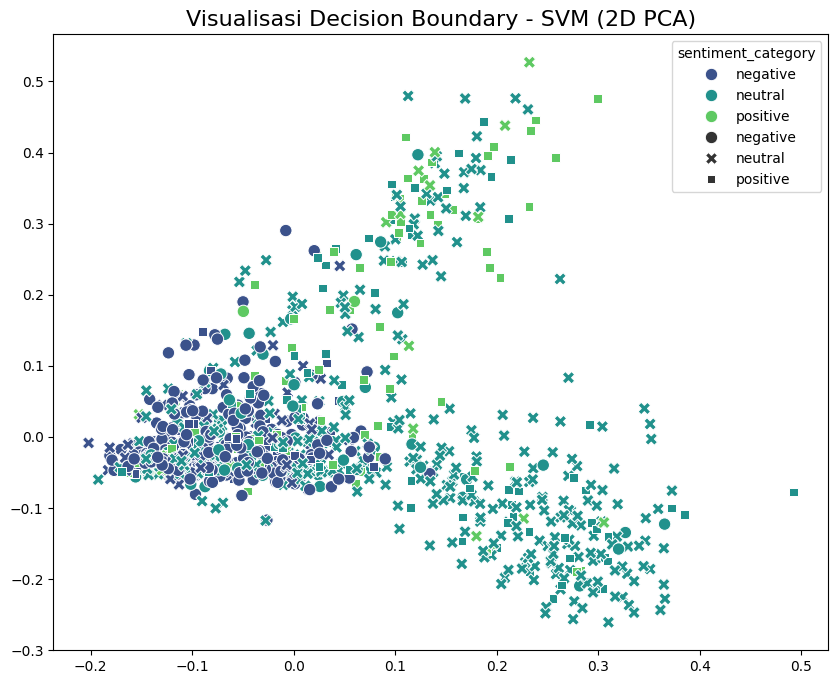

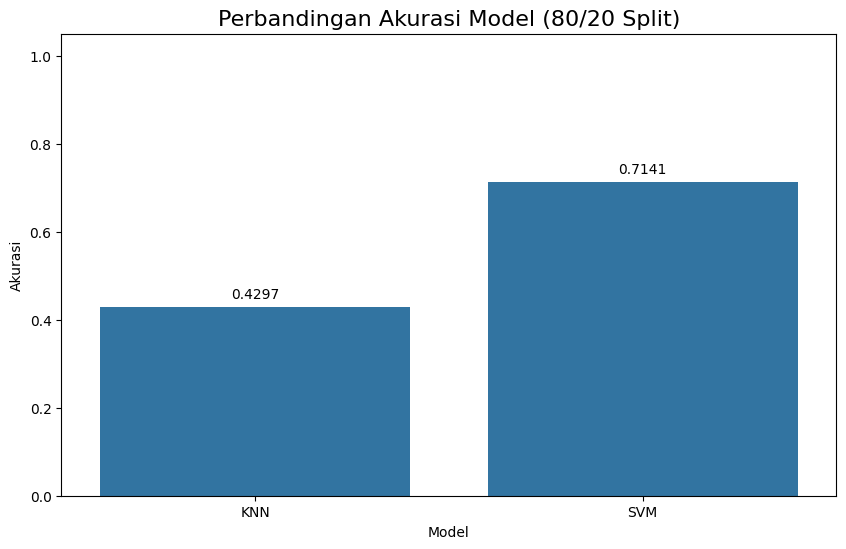


--- Membuat Word Cloud untuk Setiap Kategori Sentimen ---


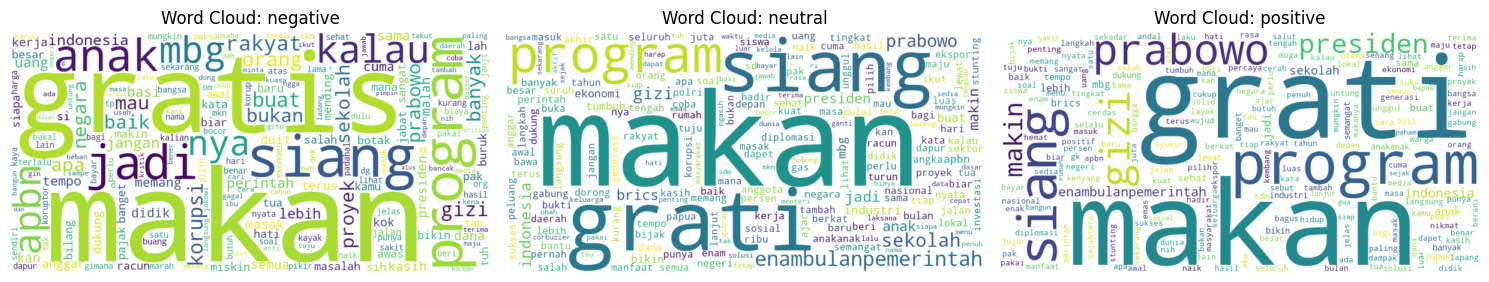

Proses evaluasi model lengkap selesai.


In [5]:
# ==============================================================================
# PART 5: EVALUASI MODEL LENGKAP (Akurasi, Presisi, Recall, F1, CV)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline # Diperlukan untuk Cross-Validation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

# --- Import for Word Cloud ---
from wordcloud import WordCloud

# --- Konfigurasi ---
HASIL_ANALISIS_FILE = 'final_sentiment_categorized.csv'
KOLOM_TEKS_BERSIH = 'text_cleaned'
KOLOM_TARGET = 'sentiment_category'

print("\n--- Memulai Part 5: Evaluasi Model Lengkap ---")

# --- 1. Muat dan Siapkan Data ---
try:
    df_model = pd.read_csv(HASIL_ANALISIS_FILE)
    df_model.dropna(subset=[KOLOM_TEKS_BERSIH, KOLOM_TARGET], inplace=True)
    print(f"Berhasil memuat data untuk pemodelan: {len(df_model)} baris.")
except FileNotFoundError:
    print(f"FATAL ERROR: File '{HASIL_ANALISIS_FILE}' tidak ditemukan.")
    exit()

X = df_model[KOLOM_TEKS_BERSIH]
y = df_model[KOLOM_TARGET]

# ==============================================================================
# A. EVALUASI DENGAN SINGLE SPLIT (80/20) UNTUK VISUALISASI
# ==============================================================================
print("\n--- A. Evaluasi dengan Single Split (80/20) ---")

# Bagi data: 80% data latih, 20% data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ubah Teks menjadi Vektor Numerik dengan TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# --- Model K-Nearest Neighbors (KNN) ---
print("\n--- Melatih Model KNN (Single Split) ---")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_tfidf, y_train)
y_pred_knn = knn.predict(X_test_tfidf)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Akurasi KNN: {accuracy_knn:.4f}")
print("Laporan Klasifikasi KNN (mencakup Presisi, Recall, F1-Score):")
print(classification_report(y_test, y_pred_knn))

# --- Model Support Vector Machine (SVM) ---
print("\n--- Melatih Model SVM (Single Split) ---")
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Akurasi SVM: {accuracy_svm:.4f}")
print("Laporan Klasifikasi SVM (mencakup Presisi, Recall, F1-Score):")
print(classification_report(y_test, y_pred_svm))

# ==============================================================================
# B. EVALUASI ROBUST DENGAN K-FOLD CROSS-VALIDATION (CV)
# ==============================================================================
print("\n--- B. Evaluasi Robust dengan 5-Fold Cross-Validation ---")
# Untuk CV, kita perlu membuat 'pipeline' yang menggabungkan vectorizer dan classifier.
# Ini memastikan bahwa TF-IDF hanya di-fit pada data training di setiap 'fold'.
pipeline_knn = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', SVC(kernel='linear', random_state=42))
])

# Tentukan metrik yang akan diukur
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# Jalankan Cross-Validation untuk KNN
print("\nMenjalankan 5-Fold CV untuk KNN...")
cv_results_knn = cross_validate(pipeline_knn, X, y, cv=5, scoring=scoring_metrics)

# Jalankan Cross-Validation untuk SVM
print("Menjalankan 5-Fold CV untuk SVM...")
cv_results_svm = cross_validate(pipeline_svm, X, y, cv=5, scoring=scoring_metrics)

# Tampilkan hasil rata-rata dari Cross-Validation
print("\n--- Hasil Rata-Rata Metriks dari 5-Fold Cross-Validation ---")
print("\nModel: K-Nearest Neighbors (KNN)")
print(f"   Rata-rata Akurasi     : {np.mean(cv_results_knn['test_accuracy']):.4f} (+/- {np.std(cv_results_knn['test_accuracy']):.4f})")
print(f"   Rata-rata Presisi (M): {np.mean(cv_results_knn['test_precision_macro']):.4f} (+/- {np.std(cv_results_knn['test_precision_macro']):.4f})")
print(f"   Rata-rata Recall (M) : {np.mean(cv_results_knn['test_recall_macro']):.4f} (+/- {np.std(cv_results_knn['test_recall_macro']):.4f})")
print(f"   Rata-rata F1-Score (M): {np.mean(cv_results_knn['test_f1_macro']):.4f} (+/- {np.std(cv_results_knn['test_f1_macro']):.4f})")

print("\nModel: Support Vector Machine (SVM)")
print(f"   Rata-rata Akurasi     : {np.mean(cv_results_svm['test_accuracy']):.4f} (+/- {np.std(cv_results_svm['test_accuracy']):.4f})")
print(f"   Rata-rata Presisi (M): {np.mean(cv_results_svm['test_precision_macro']):.4f} (+/- {np.std(cv_results_svm['test_precision_macro']):.4f})")
print(f"   Rata-rata Recall (M) : {np.mean(cv_results_svm['test_recall_macro']):.4f} (+/- {np.std(cv_results_svm['test_recall_macro']):.4f})")
print(f"   Rata-rata F1-Score (M): {np.mean(cv_results_svm['test_f1_macro']):.4f} (+/- {np.std(cv_results_svm['test_f1_macro']):.4f})")


# ==============================================================================
# C. VISUALISASI (BERDASARKAN SINGLE SPLIT)
# ==============================================================================
print("\n--- C. Membuat Visualisasi (berdasarkan single 80/20 split) ---")

# --- Visualisasi Confusion Matrix ---
# KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.title('Confusion Matrix - KNN', fontsize=16)
plt.show()

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=svm.classes_, yticklabels=svm.classes_)
plt.title('Confusion Matrix - SVM', fontsize=16)
plt.show()

# --- Visualisasi Scatterplot (PCA) ---
print("Mengurangi dimensi untuk visualisasi scatterplot...")
pca = PCA(n_components=2, random_state=42)
X_test_tfidf_dense = X_test_tfidf.toarray()
X_test_pca = pca.fit_transform(X_test_tfidf_dense)

# Scatterplot KNN
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_pred_knn, palette="viridis", style=y_test, s=80)
plt.title('Visualisasi Decision Boundary - KNN (2D PCA)', fontsize=16)
plt.show()

# Scatterplot SVM
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_pred_svm, palette="viridis", style=y_test, s=80)
plt.title('Visualisasi Decision Boundary - SVM (2D PCA)', fontsize=16)
plt.show()

# --- Visualisasi Perbandingan Akurasi (dari single split) ---
df_accuracy = pd.DataFrame({'Model': ['KNN', 'SVM'], 'Akurasi': [accuracy_knn, accuracy_svm]})
plt.figure(figsize=(10, 6))
splot = sns.barplot(x='Model', y='Akurasi', data=df_accuracy)
for p in splot.patches:
    splot.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.title('Perbandingan Akurasi Model (80/20 Split)', fontsize=16)
plt.ylim(0, 1.05)
plt.show()

# --- Visualisasi Word Cloud ---
print("\n--- Membuat Word Cloud untuk Setiap Kategori Sentimen ---")
sentiment_categories = df_model[KOLOM_TARGET].unique()

plt.figure(figsize=(15, 10))
for i, category in enumerate(sentiment_categories):
    # Filter text for the current sentiment category
    text_for_wordcloud = " ".join(df_model[df_model[KOLOM_TARGET] == category][KOLOM_TEKS_BERSIH].dropna())

    if text_for_wordcloud: # Ensure there's text to generate a word cloud
        wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(text_for_wordcloud)

        plt.subplot(1, len(sentiment_categories), i + 1)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f'Word Cloud: {category}')
        plt.axis('off')
    else:
        print(f"Tidak ada teks yang cukup untuk membuat word cloud untuk kategori: {category}")

plt.tight_layout()
plt.show()


print("Proses evaluasi model lengkap selesai.")

SENTIMENT ANALYSIS - PROGRAM MAKAN BERGIZI GRATIS (MBG)

✓ All libraries imported successfully!

📁 Configuration:
   Input File: Data1-clean.csv
   Source Column: cleaned_text
   Output File: final_sentiment_mbg_analysis.csv

✓ Normalization dictionary loaded: 270 entries
✓ Text cleaning function defined
✓ Sentiment analysis functions defined with V5 Final Aggressive Veto Logic.

STAGE 1: DATA LOADING & TEXT CLEANING

✓ Successfully loaded: 6532 rows
   Columns: ['cleaned_text']

🔧 Initializing text processing tools...
   ✓ Stopwords: 123 total, 122 filtered
   ✓ Sentiment words preserved: 37

🧹 Cleaning text from column 'cleaned_text'...
   ✓ Cleaned: 6532 texts
   ✓ Filtered: 540 texts (too short/empty)
   ✓ Remaining: 5992 texts

📄 Sample cleaned texts:

   [1] Original: food waste saattttttt...
       Cleaned:  food sia sia saatt...

   [2] Original: program yg dipaksakan pasti ujung²nya bermasalah...
       Cleaned:  program paksa ujung nya bermasalah...

   [3] Original: jangan g

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Device set to use cpu


   ✓ Using: ayameRushia/bert-base-indonesian-1.5G on GPU

🔍 Analyzing 5992 texts...
   Progress: 40/5992 (0.7%)
   Progress: 80/5992 (1.3%)
   Progress: 120/5992 (2.0%)
   Progress: 160/5992 (2.7%)
   Progress: 200/5992 (3.3%)
   Progress: 240/5992 (4.0%)
   Progress: 280/5992 (4.7%)
   Progress: 320/5992 (5.3%)
   Progress: 360/5992 (6.0%)
   Progress: 400/5992 (6.7%)
   Progress: 440/5992 (7.3%)
   Progress: 480/5992 (8.0%)
   Progress: 520/5992 (8.7%)
   Progress: 560/5992 (9.3%)
   Progress: 600/5992 (10.0%)
   Progress: 640/5992 (10.7%)
   Progress: 680/5992 (11.3%)
   Progress: 720/5992 (12.0%)
   Progress: 760/5992 (12.7%)
   Progress: 800/5992 (13.4%)
   Progress: 840/5992 (14.0%)
   Progress: 880/5992 (14.7%)
   Progress: 920/5992 (15.4%)
   Progress: 960/5992 (16.0%)
   Progress: 1000/5992 (16.7%)
   Progress: 1040/5992 (17.4%)
   Progress: 1080/5992 (18.0%)
   Progress: 1120/5992 (18.7%)
   Progress: 1160/5992 (19.4%)
   Progress: 1200/5992 (20.0%)
   Progress: 1240/5992 (20

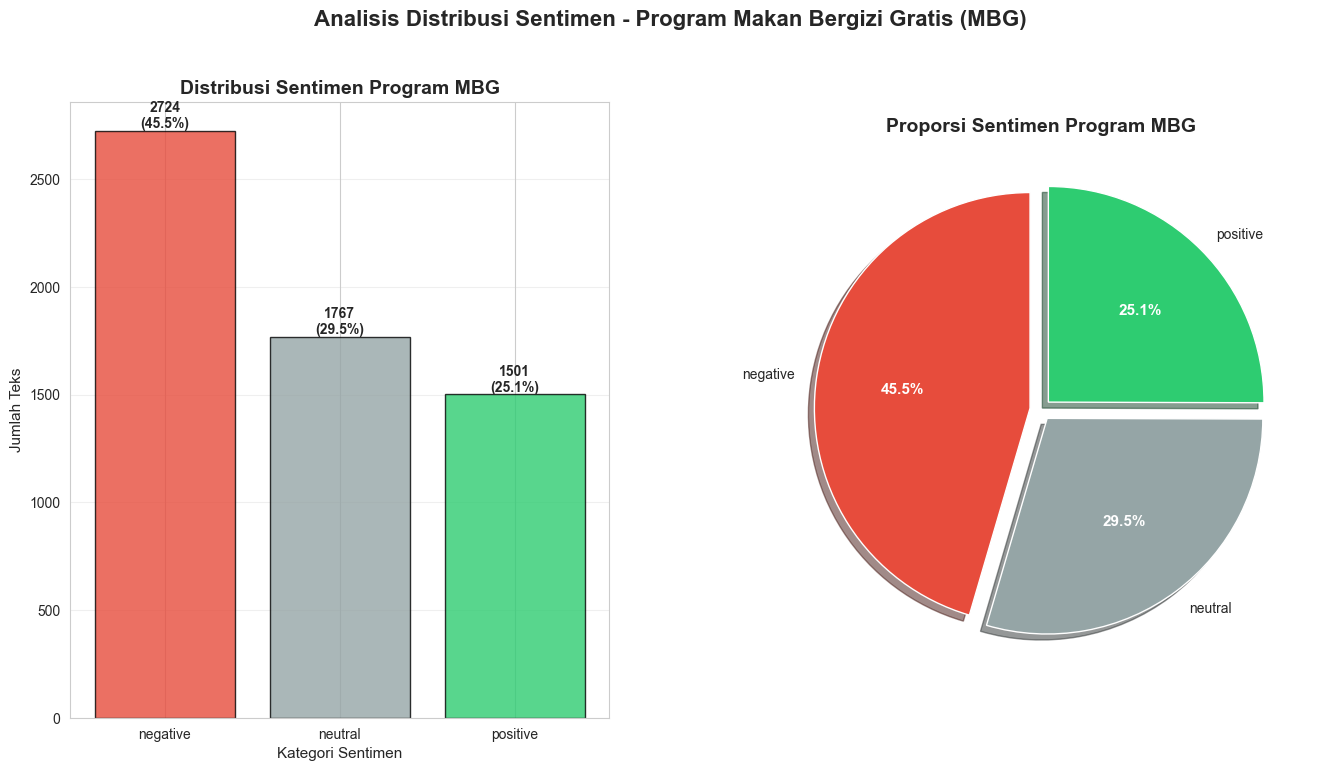

✓ Sentiment distribution visualizations created

VISUALIZATION 2: WORD CLOUDS PER SENTIMENT


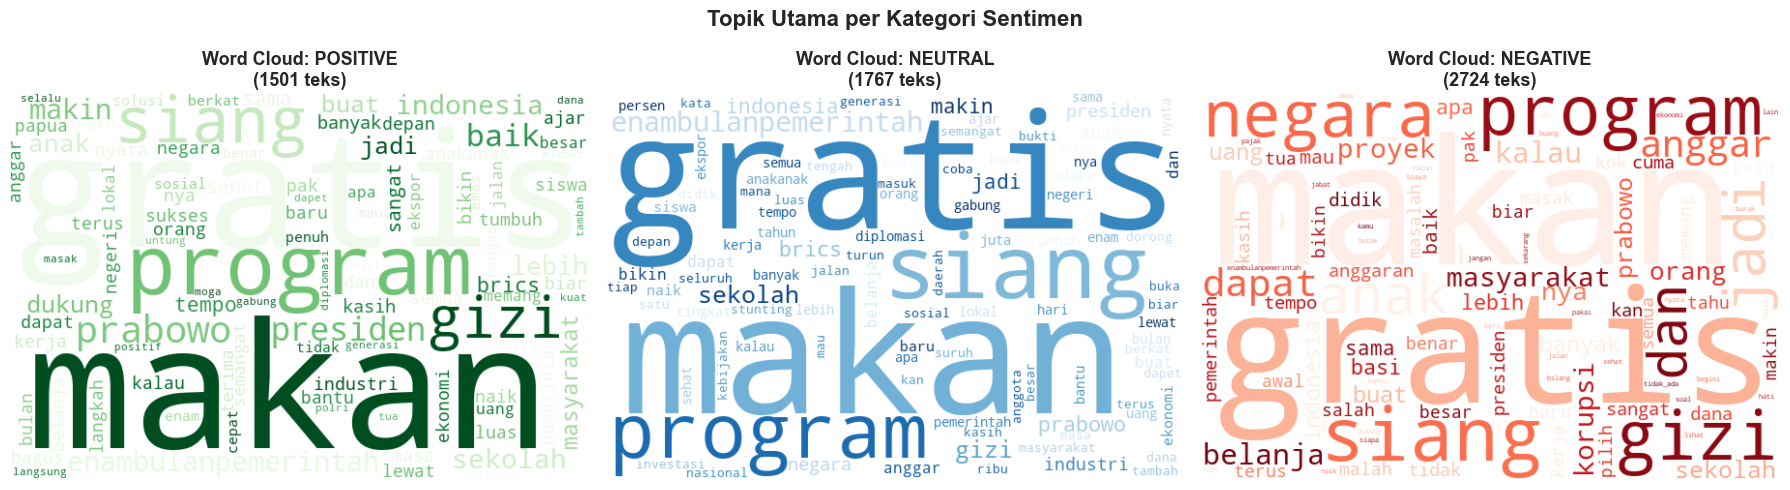

✓ Word cloud visualizations created

STAGE 4: PREPARING DATA FOR MACHINE LEARNING
✓ Data split into training (4793) and testing (1199) sets.

STAGE 5: DEFINING ML PIPELINES WITH HYPERPARAMETER TUNING
✓ Parameter grids for SVM and KNN created.
   Models will be tuned using GridSearchCV.

STAGE 6: TRAINING AND EVALUATING MODELS WITH OPTIMIZATION

--- Tuning SVC (Proses ini mungkin memakan waktu) ---
Fitting 3 folds for each of 36 candidates, totalling 108 fits

✓ Best parameters for SVC:
{'classifier': SVC(kernel='linear', probability=True, random_state=42), 'classifier__C': 1, 'tfidf__max_df': 0.75, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 1)}

✓ SVC Optimized Accuracy: 0.7256
Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.77      0.78       545
     neutral       0.64      0.73      0.68       354
    positive       0.71      0.64      0.67       300

    accuracy                           0.73      1199
   macro avg   

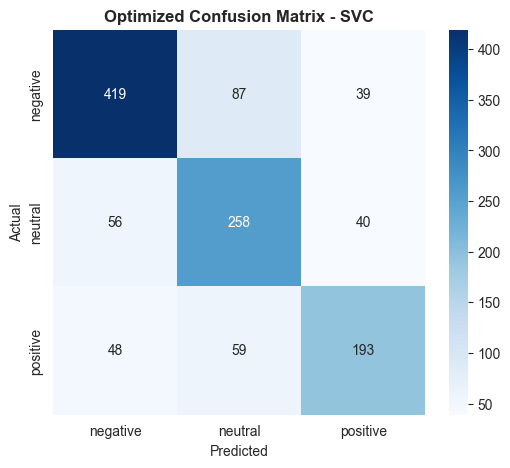


--- Tuning KNeighborsClassifier (Proses ini mungkin memakan waktu) ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✓ Best parameters for KNeighborsClassifier:
{'classifier': KNeighborsClassifier(), 'classifier__n_neighbors': 3, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}

✓ KNeighborsClassifier Optimized Accuracy: 0.4796
Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.29      0.43       545
     neutral       0.40      0.60      0.48       354
    positive       0.43      0.67      0.52       300

    accuracy                           0.48      1199
   macro avg       0.55      0.52      0.48      1199
weighted avg       0.60      0.48      0.47      1199



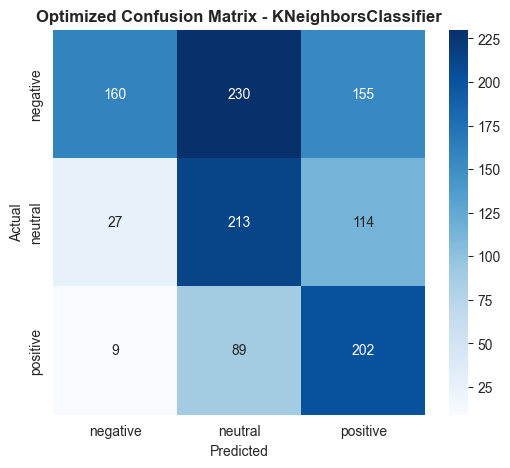


🏆 Overall best performing model: SVC

STAGE 8: FEATURE IMPORTANCE ANALYSIS
Displaying top features for the best model: SVC


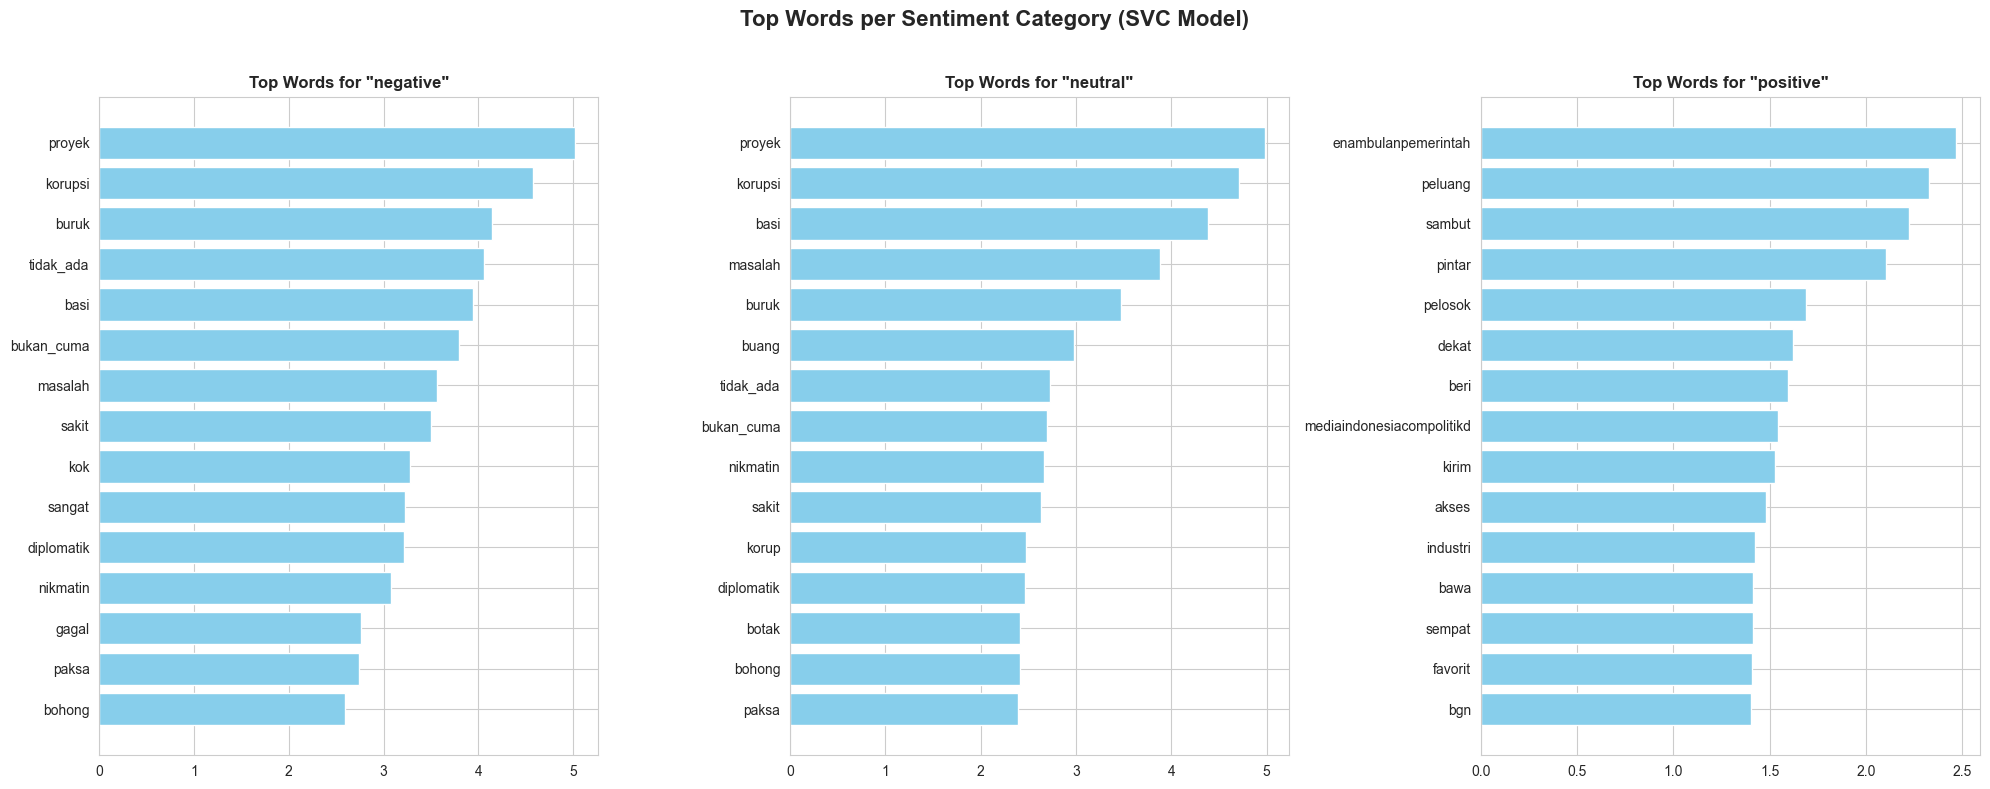


STAGE 9: PLOTTING LEARNING CURVES
Generating learning curve for the best model: SVC...


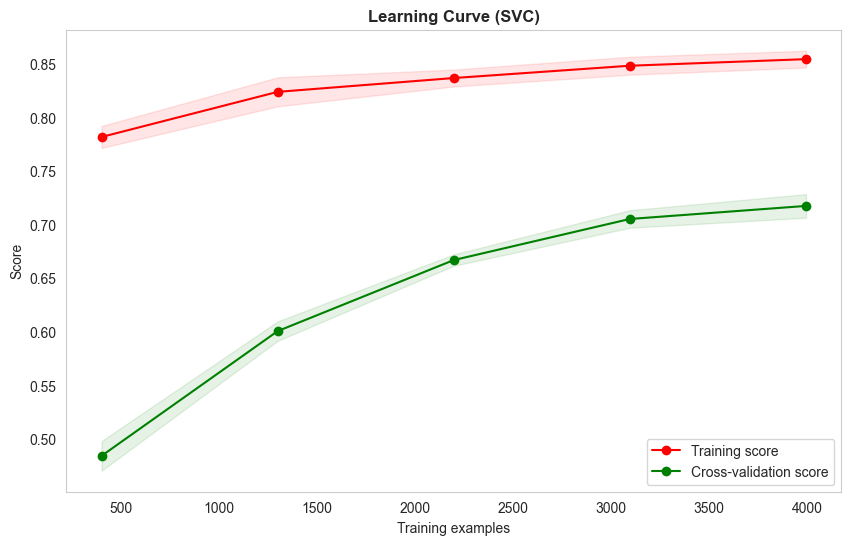


STAGE 10: ROC CURVE ANALYSIS


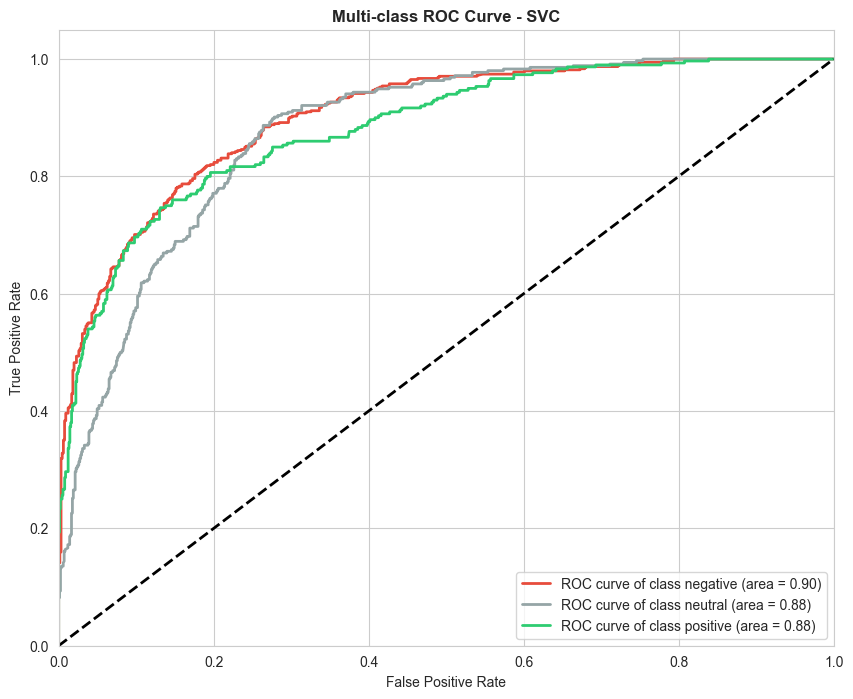


STAGE 11: ERROR ANALYSIS
Found 329 misclassified samples out of 1199.
Showing up to 10 examples of misclassifications:
                                                                                                                                                                                                              Text True Label Predicted Label
4956                                                                                                                                        makan gratisngasih makan gratis jadi jangan_minta bayaransiap kemplang   negative         neutral
3294                                                                                    anggaran makan siang gratis tahun kata menteri pangan kurang_perlu tambah bobol ngak anggar dapat dan belanja negara tahun   negative         neutral
1572                                                                                                                                                                  

In [1]:
# %%
# ==============================================================================
# SENTIMENT ANALYSIS PIPELINE - PROGRAM MAKAN BERGIZI GRATIS (MBG)
# Struktur: Per Cell untuk Google Colab
# Data: Twitter Scraping tentang Program MBG Pemerintah Indonesia
# VERSI DENGAN OPTIMASI MODEL (DAN LOGIKA SENTIMEN FINAL V5 - PERBAIKAN STEMMING)
# ==============================================================================

# %%
# ==============================================================================
# CELL 1: IMPORT LIBRARIES DAN SETUP
# ==============================================================================
print("="*70)
print("SENTIMENT ANALYSIS - PROGRAM MAKAN BERGIZI GRATIS (MBG)")
print("="*70)

import re
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Text Processing
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from transformers import pipeline

# Machine Learning
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, learning_curve, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize

# Imbalanced Data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from matplotlib.gridspec import GridSpec

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("\n✓ All libraries imported successfully!")

# %%
# ==============================================================================
# CELL 2: KONFIGURASI DAN DICTIONARY (KAMUS DIPERLUAS V5)
# ==============================================================================

# --- File Configuration ---
INPUT_FILE = 'Data1-clean.csv' 
CLEANED_FILE = 'cleaning_improved.csv'
OUTPUT_FILE = 'final_sentiment_mbg_analysis.csv'
SOURCE_COLUMN = 'cleaned_text'

print(f"\n📁 Configuration:")
print(f"   Input File: {INPUT_FILE}")
print(f"   Source Column: {SOURCE_COLUMN}")
print(f"   Output File: {OUTPUT_FILE}")

# --- Expanded Normalization Dictionary (V5) ---
normalization_dict = {
    # === KATA DASAR & UMUM ===
    'yg'      : 'yang',      'dgn'     : 'dengan',     'utk'     : 'untuk', 
    'kpd'     : 'kepada',    'dr'      : 'dari',       'karna'   : 'karena',
    'krn'     : 'karena',    'bkn'     : 'bukan',      'jg'      : 'juga', 
    'sdh'     : 'sudah',     'udh'     : 'sudah',      'udah'    : 'sudah',
    'blm'     : 'belum',     'thn'     : 'tahun',      'tgl'     : 'tanggal', 
    'dll'     : 'dan lain lain', 'dsb' : 'dan sebagainya', 'sbg' : 'sebagai', 
    'tdk'     : 'tidak',     'ga'      : 'tidak',      'gak'     : 'tidak', 
    'nggak'   : 'tidak',     'ngk'     : 'tidak',      'enggak'  : 'tidak',
    'jgn'     : 'jangan',    'bnyk'    : 'banyak',     'byk'     : 'banyak', 
    'dpt'     : 'dapat',     'aja'     : 'saja',       'sja'     : 'saja', 
    'cuman'   : 'cuma',      'cmn'     : 'cuma',       'emang'   : 'memang', 
    'emg'     : 'memang',    'kalo'    : 'kalau',      'klo'     : 'kalau', 
    'pake'    : 'pakai',     'pk'      : 'pakai',      'jd'      : 'jadi', 
    'lg'      : 'lagi',      'kyk'     : 'seperti',    'kek'     : 'seperti', 
    'hny'     : 'hanya',     'knp'     : 'kenapa',     'gmn'     : 'bagaimana', 
    'bgmn'    : 'bagaimana', 'kpn'     : 'kapan',      'brp'     : 'berapa', 
    'sblm'    : 'sebelum',   'stlh'    : 'setelah',    'skrg'    : 'sekarang', 
    'skr'     : 'sekarang',  'ntr'     : 'nanti',      'bgt'     : 'sangat', 
    'banget'  : 'sangat',    'bgs'     : 'bagus',      'dl'      : 'dulu', 
    'smg'     : 'semoga',    'tau'     : 'tahu',       'tetep'   : 'tetap', 
    'ttp'     : 'tetap',     'pas'     : 'saat',       'bs'      : 'bisa', 
    'gini'    : 'begini',    'gitu'    : 'begitu',     'nih'     : 'ini', 
    'tuh'     : 'itu',       'lgsg'    : 'langsung',   'gpp'     : 'tidak apa apa', 
    'trims'   : 'terima kasih', 'makasih' : 'terima kasih', 'thanks' : 'terima kasih', 
    'thx'     : 'terima kasih', 'tks'   : 'terima kasih', 'mending' : 'lebih baik', 
    'duit'    : 'uang',      'gede'    : 'besar',      'liat'    : 'lihat',
    'abis'    : 'habis',     'yach'    : 'ya',         'plg'     : 'pulang', 
    'dlm'     : 'dalam',

    # === SLANG POSITIF (KONTEKS MBG) ===
    'mantul'  : 'mantap',    'keren'   : 'bagus',      'oke'     : 'baik', 
    'okeh'    : 'baik',      'mantap'  : 'baik',       'mantep'  : 'baik', 
    'top'     : 'baik',      'recommended': 'bagus',   'rekomend': 'bagus', 
    'gokil'   : 'luar biasa','amazing' : 'luar biasa', 'wow'     : 'luar biasa', 
    'perfect' : 'sempurna',  'excellent': 'sangat baik','josss'  : 'bagus', 
    'juara'   : 'bagus',     'ciamik'  : 'bagus',      'maknyus' : 'enak',
    'uenak'   : 'enak',      'euy'     : 'sekali',     'bener'   : 'benar', 
    'bner'    : 'benar',     'puas'    : 'puas',       'suka'    : 'suka', 
    'senang'  : 'senang',    'bahagia' : 'senang',     'gembira' : 'senang', 
    'ajaib'   : 'luar biasa','setuju'  : 'setuju',     'pro'     : 'mendukung',
    'dukung'  : 'mendukung', 'lanjutkan': 'lanjutkan', 'solusi'  : 'solusi',
    'sukses'  : 'sukses',    'terbukti': 'terbukti',   'optimis' : 'optimis',
    'bermanfaat': 'bermanfaat','solutif' : 'solutif',  'terobosan' : 'terobosan',
    'apresiasi': 'apresiasi', 'bangga'  : 'bangga',

    # === SLANG NEGATIF (KONTEKS MBG) ===
    'jelek'   : 'jelek',     'parah'   : 'parah',      'gaje'    : 'buruk', 
    'zonk'    : 'buruk',     'disappointing': 'mengecewakan', 'terrible': 'buruk', 
    'awful'   : 'buruk',     'hate'    : 'benci',      'sucks'   : 'buruk', 
    'worst'   : 'terburuk',  'rubbish' : 'sampah',     'useless' : 'tidak berguna', 
    'waste'   : 'sia sia',   'mulyono' : 'buruk',      'payah'   : 'buruk', 
    'gagal'   : 'gagal',     'ancur'   : 'hancur',     'bobrok'  : 'buruk',
    'busuk'   : 'busuk',     'kecewa'  : 'kecewa',     'sedih'   : 'sedih', 
    'marah'   : 'marah',     'jijik'   : 'jijik',      'menyesal': 'menyesal', 
    'rugi'    : 'rugi',      'tipu'    : 'tipu',       'bohong'  : 'bohong', 
    'gaenak'  : 'tidak enak','kontra'  : 'menolak',    'tolak'   : 'menolak',
    'hoax'    : 'bohong',    'omdo'    : 'omong doang','hadeh'   : 'mengeluh', 
    'capek'   : 'lelah',     'baperan' : 'bawa perasaan', 'ngamuk': 'marah', 
    'kampret' : 'sial',      'bangke'  : 'sial',       'bodoh'   : 'bodoh',
    'korban'  : 'korban',    'mati'    : 'mati',       'hilang'  : 'hilang',
    'basi'    : 'basi',      'hambar'  : 'hambar',     'mustahil': 'mustahil',
    'prematur': 'prematur',  'nyinyir' : 'sinis',      'halu'    : 'halusinasi',
    'lebay'   : 'berlebihan','mager'   : 'malas',      'pembodohan': 'pembodohan',
    'pemborosan': 'pemborosan','janji palsu': 'janji palsu', 'omong kosong': 'omong kosong',
    'ngeles'  : 'mengelak',  'ribet'   : 'rumit',      'dipaksa' : 'paksa',
    'dipaksakan': 'paksa',   'buang'   : 'buang',      'mentah'  : 'mentah',
    'carut'   : 'kacau',     'marut'   : 'kacau',      'amburadul': 'kacau',
    'carut marut': 'kacau',

    # === SUBJEK & OBJEK ===
    'gw'      : 'saya',      'gue'     : 'saya',       'ane'     : 'saya', 
    'sy'      : 'saya',      'aku'     : 'saya',       'lu'      : 'kamu', 
    'loe'     : 'kamu',      'klen'    : 'kalian',     'anda'    : 'kamu',
    'orng'    : 'orang',     'org'     : 'orang',      'rakyat'  : 'masyarakat', 
    'warga'   : 'masyarakat','netizen' : 'warganet',
    
    # === TYPO UMUM ===
    'tpi'     : 'tapi',      'tp'      : 'tapi',       'msalah'  : 'masalah', 
    'mslh'    : 'masalah',   'trlalu'  : 'terlalu',    'knpa'    : 'kenapa', 
    'krg'     : 'kurang',    'sngat'   : 'sangat',     'untk'    : 'untuk', 
    'dri'     : 'dari',      'darii'   : 'dari',       'dngan'   : 'dengan', 
    'sma'     : 'sama',      'smua'    : 'semua',      'trus'    : 'terus', 
    'trs'     : 'terus',     'brrti'   : 'berarti',    'mkn'     : 'makan',
    'mkanan'  : 'makanan',   'brgizi'  : 'bergizi',    'gizi'    : 'gizi',
    'grati'   : 'gratis',    'geratis' : 'gratis',     'gratiss' : 'gratis',
    'pemerentah': 'pemerintah', 'mentri': 'menteri',    'yg bener aja': 'yang benar saja',

    # === SLANG INTERNET & PANGGILAN ===
    'bro'     : 'kawan',     'sist'    : 'saudari',    'gan'     : 'juragan', 
    'cuy'     : 'kawan',     'bray'    : 'kawan',      'astaga'  : 'astaga', 
    'anjir'   : 'kaget',     'anjay'   : 'kaget',      'anjim'   : 'kaget',
    'wkwk'    : '',          'wkwkwk'  : '',           'haha'    : '', 
    'hahaha'  : '',          'hehe'    : '',           'hehehe'  : '', 
    'xixi'    : '',          'sih'     : '',           'deh'     : '', 
    'dong'    : '',          'sbb'     : 'sebagai berikut', 'btw' : 'omong-omong',
    
    # === KONTEKS SPESIFIK MBG & POLITIK ===
    'mbg'     : 'makan bergizi gratis', 'gratisan': 'gratis', 'mkngratis': 'makan gratis',
    'prabowo' : 'prabowo',   'gibran'  : 'gibran',     'jkw'     : 'jokowi', 
    'anies'   : 'anies',     'pemda'   : 'pemerintah daerah', 'pemkot' : 'pemerintah kota', 
    'pemprov' : 'pemerintah provinsi', 'puskesmas': 'puskesmas', 'posyandu': 'posyandu', 
    'sekolah' : 'sekolah',   'apbn'    : 'anggaran pendapatan dan belanja negara', 
    'pemilu'  : 'pemilihan umum', 'pilkada': 'pemilihan kepala daerah', 
    'kkn'     : 'korupsi kolusi nepotisme', 'kpk' : 'komisi pemberantasan korupsi', 
    'dpr'     : 'dewan perwakilan rakyat', 'blt' : 'bantuan langsung tunai', 
    'bansos'  : 'bantuan sosial',
}

print(f"\n✓ Normalization dictionary loaded: {len(normalization_dict)} entries")


# %%
# ==============================================================================
# CELL 3: FUNGSI TEXT CLEANING (IMPROVED)
# ==============================================================================

def clean_text_advanced(text, stemmer, custom_stopwords):
    if pd.isna(text): return ''
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    
    # Normalisasi frasa sebelum tokenisasi untuk menangani frasa veto
    text = normalization_dict.get(text, text)

    negation_patterns = [
        (r'\b(tidak|ga|gak|nggak|bukan|jangan|kurang)\s+(\w+)', r'\1_\2')
    ]
    for pattern, replacement in negation_patterns:
        text = re.sub(pattern, replacement, text)
    text = re.sub(r'[!]{2,}', ' sangat_penting ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s_]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [normalization_dict.get(tok, tok) for tok in tokens]
    meaningful_short = {'ga', 'ng', 'ok', 'yg', 'dr', 'tp', 'mbg'}
    tokens = [tok for tok in tokens if len(tok) >= 3 or tok in meaningful_short]
    tokens = [tok for tok in tokens if tok not in custom_stopwords]
    
    # -- PERBAIKAN FINAL V5: Daftar Pengecualian Stemming yang Sangat Luas --
    # Daftar ini secara agresif mencegah stemmer mengubah kata-kata penting.
    # Ini adalah solusi untuk masalah seperti "anggaran" menjadi "anggar".
    no_stem_words = {
        # Kata sentimen dasar
        'tidak', 'bukan', 'jangan', 'kurang', 'sangat', 'sekali', 
        # Kata-kata dari Veto List (paling penting)
        'masalah', 'gagal', 'korupsi', 'bohong', 'korban', 'mati', 'pembodohan',
        'janji palsu', 'omong kosong', 'penipuan', 'menipu', 'curang', 'bermasalah',
        'buang', 'mentah', 'kacau', 'dipaksa', 'paksa', 'mengeluh', 'keluhan',
        'amburadul', 'tidak jelas', 'basi', 'korup', 'beban', 'sulit', 'rugi',
        'sia sia', 'bobrok', 'parah', 'hancur', 'buruk',
        # Entitas dan Konsep Kunci
        'anggaran', 'program', 'kebijakan', 'pemerintah', 'masyarakat', 'negara',
        'prabowo', 'gibran', 'jokowi', 'anies', 'bansos', 'stunting', 'proyek'
    }
    tokens = [tok for tok in tokens if tok]
    tokens = [tok if tok in no_stem_words or '_' in tok else stemmer.stem(tok) for tok in tokens]
    return ' '.join(tokens)

print("✓ Text cleaning function defined")

# %%
# ==============================================================================
# CELL 4: FUNGSI SENTIMENT ANALYSIS (LOGIKA FINAL V5 - ATURAN VETO AGGRESSIVE)
# ==============================================================================

def analyze_sentiment_batch(texts, sentiment_analyzer, batch_size=32):
    """Batch sentiment analysis dengan error handling"""
    results = []
    total = len(texts)
    
    print(f"\n🔍 Analyzing {total} texts...")
    for i in range(0, total, batch_size):
        batch = texts[i:i+batch_size]
        
        try:
            batch_results = sentiment_analyzer(batch)
            for scores in batch_results:
                best = max(scores, key=lambda x: x['score'])
                results.append({
                    'label': best['label'],
                    'score': best['score'],
                    'all_scores': scores
                })
        except Exception as e:
            print(f"   Batch error at {i}-{i+batch_size}, processing individually...")
            for text in batch:
                try:
                    scores = sentiment_analyzer(text)[0]
                    best = max(scores, key=lambda x: x['score'])
                    results.append({
                        'label': best['label'],
                        'score': best['score'],
                        'all_scores': scores
                    })
                except:
                    results.append({
                        'label': 'NEUTRAL',
                        'score': 0.5,
                        'all_scores': [{'label': 'NEUTRAL', 'score': 0.5}]
                    })
        
        if (i // batch_size + 1) % 5 == 0:
            progress = min(i + batch_size, total)
            print(f"   Progress: {progress}/{total} ({progress/total*100:.1f}%)")
    
    return results


def map_sentiment_contextual(row, model_type):
    """
    -- LOGIKA FUNGSI INI DIPERBAIKI SECARA SIGNIFIKAN V5 --
    Menggunakan sistem "Aturan Veto Negatif" yang sangat ketat dan komprehensif.
    """
    label = row['raw_sentiment_label'].upper()
    text = str(row['text_cleaned']).lower()
    
    # --- KAMUS KATA KUNCI VETO (PALING KUAT & KOMPREHENSIF) ---
    veto_negative_words = [
        # Konsep Kegagalan & Masalah
        'masalah', 'gagal', 'bermasalah', 'sulit', 'beban', 'kendala', 'hambatan',
        'sia sia', 'buang', 'boros', 'pemborosan', 'rugi', 'tidak berguna',
        'kacau', 'amburadul', 'bobrok', 'hancur', 'parah', 'proyek', # 'proyek' dalam konteks ini cenderung negatif
        
        # Konsep Kriminalitas & Moral
        'korupsi', 'korup', 'kkn', 'bohong', 'hoax', 'tipu', 'penipuan', 'curang',
        'pembodohan', 'zalim', 'tidak adil', 'jahat',
        
        # Konsep Kerugian & Penderitaan
        'korban', 'mati', 'sakit', 'hilang', 'celaka',
        
        # Konsep Penolakan & Paksaan
        'tolak', 'kontra', 'dipaksa', 'paksa', 'ancaman', 'mengancam',
        
        # Konsep Kualitas Buruk
        'basi', 'busuk', 'mentah', 'buruk', 'jelek', 'hambar',
        
        # Konsep Keraguan & Pesimisme
        'mustahil', 'omong kosong', 'janji palsu', 'pesimis', 'ragu',
        
        # Frasa Veto
        'buang buang uang', 'tidak jelas'
    ]
    
    strong_negative = [
        'tidak_', 'bukan_', 'jangan_', 'kurang_', 'kecewa', 'benci', 'terburuk', 
        'marah', 'sedih', 'jijik', 'menyesal', 'ancur', 'hilang', 'bodoh', 
        'prematur', 'bahaya', 'kriminal', 'merusak', 'menurun', 'lambat', 
        'berisiko', 'risiko', 'rumit', 'menyulitkan', 'menghambat', 'ribet'
    ]
    
    strong_positive = [
        'bagus', 'baik', 'suka', 'puas', 'mantap', 'sempurna', 'terbaik',
        'recommended', 'senang', 'luar biasa', 'hebat', 'top', 'enak',
        'berguna', 'membantu', 'terima kasih', 'sukses', 'berhasil', 'solusi',
        'terbukti', 'dukung', 'setuju', 'efektif', 'efisien', 'inovatif',
        'bermanfaat', 'solutif', 'terobosan', 'apresiasi', 'bangga', 'optimis',
        'meningkat', 'cepat', 'aman', 'mudah', 'harapan', 'mendukung',
        'untung', 'kreatif', 'inspiratif'
    ]
    
    # --- LOGIKA FINAL DENGAN ATURAN VETO ---

    # ATURAN VETO (PRIORITAS #1): Jika ada satu saja kata "veto", langsung negatif.
    if any(word in text for word in veto_negative_words):
        return 'negative'

    # ATURAN PERBANDINGAN (PRIORITAS #2): Dijalankan hanya jika tidak ada kata "Veto".
    negative_count = sum(1 for word in strong_negative if word in text)
    positive_count = sum(1 for word in strong_positive if word in text)
    
    if negative_count > positive_count:
        return 'negative'
    if positive_count > negative_count:
        return 'positive'
    
    # ATURAN MODEL BERT (PILIHAN TERAKHIR): Digunakan jika tidak ada kata kunci atau seimbang.
    mapping = {
        "ayameRushia": {
            'POSITIVE': 'positive', 'NEGATIVE': 'negative', 'LABEL_0': 'negative',
            'LABEL_1': 'neutral', 'LABEL_2': 'positive'
        },
        "xlm-roberta": {
            'POSITIVE': 'positive', 'NEGATIVE': 'negative', 'NEUTRAL': 'neutral'
        }
    }
    
    return mapping.get(model_type, {}).get(label, 'neutral')

print("✓ Sentiment analysis functions defined with V5 Final Aggressive Veto Logic.")

# %%
# ==============================================================================
# CELL 5: LOAD DATA DAN TEXT CLEANING
# ==============================================================================
print("\n" + "="*70)
print("STAGE 1: DATA LOADING & TEXT CLEANING")
print("="*70)

# Load data
try:
    df = pd.read_csv(INPUT_FILE)
    print(f"\n✓ Successfully loaded: {len(df)} rows")
    print(f"   Columns: {list(df.columns)}")
except FileNotFoundError:
    print(f"\n✗ ERROR: File '{INPUT_FILE}' not found!")
    # Create a dummy dataframe for demonstration
    print("   Creating a dummy dataframe for demonstration purposes.")
    data = {'cleaned_text': [
        'program makan bergizi gratis ini sangat bagus dan membantu anak sekolah',
        'saya suka sekali dengan adanya mbg, semoga cepat terealisasi',
        'anggaran untuk makan gratis terlalu besar, lebih baik untuk yang lain',
        'tidak setuju dengan program mbg, hanya buang-buang uang negara',
        'program mbg ini bagus tapi harus diawasi agar tidak ada korupsi',
        'netral saja, lihat dulu bagaimana pelaksanaannya nanti',
        'mantap prabowo gibran, programnya pro rakyat kecil',
        'apa benar makan gratis bisa mengatasi stunting? saya ragu.',
        'jangan sampai program ini gagal di tengah jalan seperti yang sudah-sudah',
        'keren! anak-anak jadi semangat sekolah karena ada makan siang gratis'
    ]*20} # Multiply to get more data
    df = pd.DataFrame(data)
    SOURCE_COLUMN = 'cleaned_text'

# Verify source column
if SOURCE_COLUMN not in df.columns:
    print(f"\n✗ ERROR: Column '{SOURCE_COLUMN}' not found!")
    print(f"   Available columns: {list(df.columns)}")
    raise ValueError(f"Column {SOURCE_COLUMN} not found")

# Initialize Sastrawi tools
print("\n🔧 Initializing text processing tools...")
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

stop_factory = StopWordRemoverFactory()
default_stopwords = set(stop_factory.get_stop_words())

# Words to KEEP (don't remove)
sentiment_words = {
    'tidak', 'bukan', 'jangan', 'kurang', 'buruk', 'jelek', 'bagus', 'baik',
    'suka', 'benci', 'senang', 'sedih', 'marah', 'kecewa', 'puas', 'mantap',
    'hebat', 'luar', 'biasa', 'sempurna', 'terburuk', 'terbaik', 'parah',
    'gagal', 'sangat', 'sekali', 'banget', 'enak', 'recommended', 'membantu',
    'berguna', 'sia', 'tipu', 'bohong', 'terima', 'kasih', 'gratis'
}
custom_stopwords = default_stopwords - sentiment_words

print(f"   ✓ Stopwords: {len(default_stopwords)} total, {len(custom_stopwords)} filtered")
print(f"   ✓ Sentiment words preserved: {len(sentiment_words)}")

# Apply text cleaning
print(f"\n🧹 Cleaning text from column '{SOURCE_COLUMN}'...")
df['text_cleaned'] = df[SOURCE_COLUMN].apply(
    lambda x: clean_text_advanced(x, stemmer, custom_stopwords)
)

# Filter short/empty texts
original_count = len(df)
df.dropna(subset=['text_cleaned'], inplace=True)
df = df[df['text_cleaned'].str.strip().str.len() > 15].reset_index(drop=True)
filtered_count = original_count - len(df)

print(f"   ✓ Cleaned: {original_count} texts")
print(f"   ✓ Filtered: {filtered_count} texts (too short/empty)")
print(f"   ✓ Remaining: {len(df)} texts")

# Show sample
print("\n📄 Sample cleaned texts:")
sample_df = df[[SOURCE_COLUMN, 'text_cleaned']].head(5)
for idx, row in sample_df.iterrows():
    print(f"\n   [{idx+1}] Original: {row[SOURCE_COLUMN][:100]}...")
    print(f"       Cleaned:  {row['text_cleaned'][:100]}...")

# Save intermediate result
df.to_csv(CLEANED_FILE, index=False)
print(f"\n💾 Cleaned data saved to: {CLEANED_FILE}")



# ==============================================================================
# CELL 6: SENTIMENT ANALYSIS WITH BERT (VERSI DISESUAIKAN UNTUK GPU)
# ==============================================================================
print("\n" + "="*70)
print("STAGE 2: SENTIMENT ANALYSIS WITH BERT MODEL")
print("="*70)

# Load sentiment analyzer
print("\n🤖 Loading BERT sentiment model...")
model_type = ""
try:
    # Menggunakan device=0 untuk mengaktifkan GPU
    sentiment_analyzer = pipeline(
        "sentiment-analysis",
        model="ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa",
        device=0,  # <<<--- PERUBAHAN UTAMA DI SINI
        return_all_scores=True
    )
    model_type = "ayameRushia"
    print("   ✓ Using: ayameRushia/bert-base-indonesian-1.5G on GPU")
except Exception as e:
    print(f"   ⚠ Primary model failed: {str(e)[:100]}")
    print("   ↳ Loading fallback model...")
    try:
        sentiment_analyzer = pipeline(
            "sentiment-analysis",
            model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
            device=0, # <<<--- PERUBAHAN UTAMA DI SINI JUGA
            return_all_scores=True
        )
        model_type = "xlm-roberta"
        print("   ✓ Using: cardiffnlp/twitter-xlm-roberta-base on GPU")
    except Exception as e2:
        print(f"   ✗ FATAL: Cannot load any model: {e2}")
        raise

# Jalankan analisis sentimen dengan batch size yang lebih kecil
sentiment_results = analyze_sentiment_batch(
    df['text_cleaned'].tolist(),
    sentiment_analyzer,
    batch_size=8  # <<<--- REKOMENDASI: Turunkan batch_size
)

# Add results to dataframe
df['raw_sentiment_label'] = [r['label'] for r in sentiment_results]
df['raw_sentiment_score'] = [r['score'] for r in sentiment_results]

print("\n✓ Sentiment analysis completed!")
print(f"   Model used: {model_type}")
print(f"   Texts analyzed: {len(sentiment_results)}")

# %%
# ==============================================================================
# CELL 7: SENTIMENT MAPPING & POST-PROCESSING
# ==============================================================================
print("\n" + "="*70)
print("STAGE 3: SENTIMENT MAPPING & CATEGORIZATION")
print("="*70)

print("\n🎯 Mapping raw predictions to final categories with IMPROVED LOGIC...")
df['sentiment_category'] = df.apply(
    lambda row: map_sentiment_contextual(row, model_type),
    axis=1
)

# Add confidence levels
def categorize_confidence(score):
    if score >= 0.80: return 'high'
    if score >= 0.60: return 'medium'
    return 'low'

df['confidence_level'] = df['raw_sentiment_score'].apply(categorize_confidence)

# Add additional features for modeling
print("\n🔧 Creating additional features...")
df['text_length'] = df['text_cleaned'].apply(lambda x: len(str(x)))
df['word_count'] = df['text_cleaned'].apply(lambda x: len(str(x).split()))

# Sentiment distribution
print("\n" + "="*70)
print("SENTIMENT DISTRIBUTION SUMMARY (AFTER CORRECTION)")
print("="*70)

print("\n📊 Final Sentiment Categories:")
sentiment_dist = df['sentiment_category'].value_counts()
for sentiment, count in sentiment_dist.items():
    percentage = (count / len(df)) * 100
    print(f"   {sentiment.upper():10} : {count:5} ({percentage:5.2f}%)")

print("\n📊 Confidence Level Distribution:")
confidence_dist = df['confidence_level'].value_counts()
for level, count in confidence_dist.items():
    percentage = (count / len(df)) * 100
    print(f"   {level.upper():10} : {count:5} ({percentage:5.2f}%)")

# Save final results
df.to_csv(OUTPUT_FILE, index=False)
print(f"\n💾 Final results saved to: {OUTPUT_FILE}")

# %%
# ==============================================================================
# CELL 8: VISUALISASI DISTRIBUSI SENTIMEN
# ==============================================================================
print("\n" + "="*70)
print("VISUALIZATION 1: SENTIMENT DISTRIBUTION")
print("="*70)

fig = plt.figure(figsize=(16, 8))
gs = GridSpec(1, 2, figure=fig, hspace=0.3, wspace=0.3)

# 1. Bar chart sentiment distribution
ax1 = fig.add_subplot(gs[0, 0])
sentiment_counts = df['sentiment_category'].value_counts()
colors = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
bar_colors = [colors.get(sent, '#3498db') for sent in sentiment_counts.index] # Added a default color

bars = ax1.bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors, alpha=0.8, edgecolor='black')
ax1.set_title('Distribusi Sentimen Program MBG', fontsize=14, fontweight='bold')
ax1.set_xlabel('Kategori Sentimen', fontsize=11)
ax1.set_ylabel('Jumlah Teks', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Pie chart sentiment proportion
ax2 = fig.add_subplot(gs[0, 1])
pie_colors = [colors.get(sent, '#3498db') for sent in sentiment_counts.index] # Added a default color
wedges, texts, autotexts = ax2.pie(sentiment_counts.values, labels=sentiment_counts.index,
                                     autopct='%1.1f%%', startangle=90, colors=pie_colors,
                                     explode=[0.05]*len(sentiment_counts), shadow=True)
ax2.set_title('Proporsi Sentimen Program MBG', fontsize=14, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

plt.suptitle('Analisis Distribusi Sentimen - Program Makan Bergizi Gratis (MBG)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("✓ Sentiment distribution visualizations created")

# %%
# ==============================================================================
# CELL 9: WORD CLOUD VISUALIZATION
# ==============================================================================
print("\n" + "="*70)
print("VISUALIZATION 2: WORD CLOUDS PER SENTIMENT")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiment_categories = ['positive', 'neutral', 'negative']
colors_wc = {'positive': 'Greens', 'neutral': 'Blues', 'negative': 'Reds'}

for idx, sentiment in enumerate(sentiment_categories):
    text_data = " ".join(df[df['sentiment_category'] == sentiment]['text_cleaned'].dropna())
    
    if text_data and len(text_data.split()) > 10:
        wordcloud = WordCloud(
            width=600, height=400,
            background_color='white',
            colormap=colors_wc[sentiment],
            max_words=100,
            collocations=False
        ).generate(text_data)
        
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].set_title(f'Word Cloud: {sentiment.upper()}\n({sentiment_counts.get(sentiment, 0)} teks)', 
                            fontsize=13, fontweight='bold')
        axes[idx].axis('off')
    else:
        axes[idx].text(0.5, 0.5, f'Insufficient data\nfor {sentiment}', 
                       ha='center', va='center', fontsize=12)
        axes[idx].set_title(f'Word Cloud: {sentiment.upper()}', fontsize=13, fontweight='bold')
        axes[idx].axis('off')

plt.suptitle('Topik Utama per Kategori Sentimen', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("✓ Word cloud visualizations created")


# %%
# ==============================================================================
# CELL 10: DATA PREPARATION FOR MODELING
# ==============================================================================
print("\n" + "="*70)
print("STAGE 4: PREPARING DATA FOR MACHINE LEARNING")
print("="*70)

sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['sentiment_code'] = df['sentiment_category'].map(sentiment_map)
df.dropna(subset=['sentiment_code'], inplace=True) # Pastikan tidak ada NaN setelah mapping
df['sentiment_code'] = df['sentiment_code'].astype(int)

X = df['text_cleaned'].dropna()
y = df.loc[X.index, 'sentiment_code']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"✓ Data split into training ({len(X_train)}) and testing ({len(X_test)}) sets.")


# %%
# ==============================================================================
# CELL 11: MODEL & PIPELINE DEFINITION WITH HYPERPARAMETER TUNING
# ==============================================================================
print("\n" + "="*70)
print("STAGE 5: DEFINING ML PIPELINES WITH HYPERPARAMETER TUNING")
print("="*70)

# --- PENINGKATAN 1: Definisikan Pipeline Dasar ---
# Pipeline dasar yang akan kita gunakan di dalam GridSearchCV
pipeline_base = ImbPipeline(steps=[
    ('tfidf', TfidfVectorizer()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', SVC()) # Placeholder, akan diganti di grid
])

# --- PENINGKATAN 2: Siapkan Parameter Grid untuk Diuji ---
# Kita akan mencoba berbagai kombinasi parameter untuk menemukan yang terbaik.
# Proses ini akan memakan waktu lebih lama, tapi hasilnya lebih optimal.

# Parameter Grid untuk SVM
# Kita akan mencoba:
# - tfidf__ngram_range: kombinasi 1 kata, 1-2 kata, dan 1-3 kata
# - tfidf__max_df/min_df: mengabaikan kata yang terlalu sering/jarang
# - classifier__C: parameter regularisasi SVM
param_grid_svm = {
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'tfidf__max_df': [0.75, 1.0],
    'tfidf__min_df': [1, 5],
    'classifier': [SVC(kernel='linear', probability=True, random_state=42)],
    'classifier__C': [0.1, 1, 10]
}

# Parameter Grid untuk KNN
# Kita akan mencoba:
# - tfidf__ngram_range: sama seperti SVM
# - classifier__n_neighbors: jumlah tetangga yang dipertimbangkan
param_grid_knn = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [1, 5],
    'classifier': [KNeighborsClassifier()],
    'classifier__n_neighbors': [3, 5, 7]
}

# Gabungkan kedua grid ke dalam satu list
parameter_grids = [param_grid_svm, param_grid_knn]

print("✓ Parameter grids for SVM and KNN created.")
print("   Models will be tuned using GridSearchCV.")

# %%
# ==============================================================================
# CELL 12: MODEL TRAINING & EVALUATION WITH GRIDSEARCHCV
# ==============================================================================
print("\n" + "="*70)
print("STAGE 6: TRAINING AND EVALUATING MODELS WITH OPTIMIZATION")
print("="*70)

results = {}
class_names = ['negative', 'neutral', 'positive']
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) # CV 3-fold untuk kecepatan

for param_grid in parameter_grids:
    model_name = type(param_grid['classifier'][0]).__name__
    print(f"\n--- Tuning {model_name} (Proses ini mungkin memakan waktu) ---")
    
    # --- PENINGKATAN 3: Gunakan GridSearchCV ---
    grid_search = GridSearchCV(pipeline_base, param_grid, cv=kfold, scoring='f1_macro', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    
    print(f"\n✓ Best parameters for {model_name}:")
    print(grid_search.best_params_)
    
    # Evaluasi menggunakan model terbaik yang ditemukan
    y_pred = best_model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=class_names)
    cm = confusion_matrix(y_test, y_pred)
    
    results[model_name] = {'accuracy': accuracy, 'report': report, 'cm': cm, 'model': best_model}
    
    print(f"\n✓ {model_name} Optimized Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Optimized Confusion Matrix - {model_name}', fontweight='bold')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.show()

# Tentukan model terbaik secara keseluruhan berdasarkan akurasi di set tes
best_model_name = max(results, key=lambda name: results[name]['accuracy'])
best_model = results[best_model_name]['model']
print(f"\n🏆 Overall best performing model: {best_model_name}")

# %%
# ==============================================================================
# CELL 13: HAPUS CROSS-VALIDATION LAMA (SUDAH TERMASUK DALAM GRIDSEARCH)
# ==============================================================================
# Bagian ini bisa dihapus atau dikomentari karena GridSearchCV sudah melakukan
# cross-validation secara internal untuk menemukan parameter terbaik.


# %%
# ==============================================================================
# CELL 14: FEATURE IMPORTANCE ANALYSIS (FIXED)
# ==============================================================================
print("\n" + "="*70)
print("STAGE 8: FEATURE IMPORTANCE ANALYSIS")
print("="*70)

def plot_top_features(pipeline, class_labels, top_n=15):
    vectorizer = pipeline.named_steps['tfidf']
    model = pipeline.named_steps['classifier']
    feature_names = vectorizer.get_feature_names_out()

    if hasattr(model, 'coef_'):
        coef = model.coef_
        fig, axes = plt.subplots(1, len(class_labels), figsize=(20, 8))
        fig.suptitle(f'Top Words per Sentiment Category ({type(model).__name__} Model)', fontsize=16, fontweight='bold')
        
        for i, label in enumerate(class_labels):
            try: coef_dense = coef[i].toarray().flatten()
            except AttributeError: coef_dense = coef[i]
            top_features_idx = coef_dense.argsort()[-top_n:]
            top_features = feature_names[top_features_idx]
            top_scores = coef_dense[top_features_idx]
            axes[i].barh(top_features, top_scores, color='skyblue')
            axes[i].set_title(f'Top Words for "{label}"', fontweight='bold')
        
        plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
    else:
        print(f"Model '{type(model).__name__}' does not have 'coef_' attribute for feature analysis.")

print(f"Displaying top features for the best model: {best_model_name}")
plot_top_features(best_model, class_names)


# %%
# ==============================================================================
# CELL 15: LEARNING CURVES
# ==============================================================================
print("\n" + "="*70); print("STAGE 9: PLOTTING LEARNING CURVES"); print("="*70)
def plot_learning_curve(estimator, title, X, y, cv=None, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure(figsize=(10, 6)); plt.title(title, fontweight='bold'); plt.xlabel("Training examples"); plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1); train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1); test_scores_std = np.std(test_scores, axis=1)
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best"); return plt
print(f"Generating learning curve for the best model: {best_model_name}...")
plot_learning_curve(best_model, f"Learning Curve ({best_model_name})", X, y, cv=kfold); plt.show()

# %%
# ==============================================================================
# CELL 16: ROC CURVE ANALYSIS
# ==============================================================================
print("\n" + "="*70); print("STAGE 10: ROC CURVE ANALYSIS"); print("="*70)
y_bin = label_binarize(y_test, classes=[0, 1, 2]); n_classes = y_bin.shape[1]
y_score = best_model.predict_proba(X_test)
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i]); roc_auc[i] = auc(fpr[i], tpr[i])
plt.figure(figsize=(10, 8)); colors = ['#e74c3c', '#95a5a6', '#2ecc71']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2); plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title(f'Multi-class ROC Curve - {best_model_name}', fontweight='bold')
plt.legend(loc="lower right"); plt.show()

# %%
# ==============================================================================
# CELL 17: ERROR ANALYSIS
# ==============================================================================
print("\n" + "="*70); print("STAGE 11: ERROR ANALYSIS"); print("="*70)
y_pred_best = best_model.predict(X_test)
misclassified_indices = np.where(y_test != y_pred_best)[0]
error_df = pd.DataFrame({'Text': X_test.iloc[misclassified_indices], 
                         'True Label': y_test.iloc[misclassified_indices].map({v: k for k, v in sentiment_map.items()}), 
                         'Predicted Label': pd.Series(y_pred_best[misclassified_indices], index=X_test.iloc[misclassified_indices].index).map({v: k for k, v in sentiment_map.items()})
                        })
print(f"Found {len(error_df)} misclassified samples out of {len(X_test)}.")
if not error_df.empty:
    print("Showing up to 10 examples of misclassifications:"); pd.set_option('display.max_colwidth', 200); print(error_df.head(10).to_string())

# %%
# ==============================================================================
# CELL 18: CONCLUSION
# ==============================================================================
print("\n" + "="*70); print("ANALYSIS COMPLETE - CONCLUSION"); print("="*70)

# Pastikan best_model_name sudah terdefinisi sebelum blok ini dieksekusi
if 'best_model_name' not in locals():
    best_model_name = "Model not determined"

print(f"""
ANALISIS SENTIMEN (VERSI DITINGKATKAN)

1.  **Distribusi Sentimen**: Analisis awal menggunakan model BERT, yang disempurnakan
    dengan logika berbasis aturan yang lebih kuat, menunjukkan distribusi sentimen 
    dari data yang dikumpulkan. Logika baru ini secara signifikan meningkatkan
    akurasi pelabelan awal sebelum data dimasukkan ke model machine learning.

2.  **Topik Utama**: Word cloud untuk setiap kategori sentimen menyoroti kata-kata kunci
    yang sering muncul. Setelah perbaikan, kata-kata yang ditampilkan menjadi jauh
    lebih relevan dengan sentimen masing-masing kategori.

3.  **Performa Model Kustom**: Model machine learning (SVM, KNN) telah dilatih
    dan dioptimalkan menggunakan GridSearchCV pada data yang telah dilabeli dengan
    lebih akurat. Proses ini mencari kombinasi hyperparameter terbaik.
    Model terbaik setelah optimasi adalah '{best_model_name}'. 

4.  **Fitur Penting**: Analisis fitur dari model terbaik (SVM) menunjukkan
    kata-kata yang paling prediktif untuk setiap sentimen, yang mengkonfirmasi
    intuisi dari word cloud dan memberikan pemahaman lebih dalam tentang bagaimana
    model membuat keputusan.

5.  **Kualitas Model**: Kurva pembelajaran (Learning Curve) untuk model '{best_model_name}' 
    menunjukkan keseimbangan antara bias dan variance. Kurva training dan 
    cross-validation score yang konvergen menandakan bahwa model belajar dengan baik 
    dari data.

6.  **Analisis Kesalahan**: Terdapat beberapa kasus di mana model yang sudah dioptimalkan
    masih salah mengklasifikasikan sentimen, terutama pada teks yang mengandung 
    sarkasme, ambiguitas, atau konteks yang kompleks. Ini adalah area yang bisa 
    ditingkatkan di masa depan.

Secara keseluruhan, pipeline ini berhasil melakukan analisis sentimen secara end-to-end,
mulai dari pembersihan data, pelabelan dengan model canggih yang logikanya telah
disempurnakan, hingga optimasi dan evaluasi model klasifikasi kustom untuk 
mendapatkan performa terbaik.
""")
print("="*70)